**IMPORT STATEMENTS**

To load all tools/libraries
needed for the project

This cell imports all required libraries. Torch provides deep learning functionality, nn contains neural network components, DataLoader creates batches, datasets loads FashionMNIST, ToTensor converts images into tensors, matplotlib is used for visualization, and pickle helps save the trained model.

In [1]:
import torch                                    #for deep learning(Ai toolbox)
from torch import nn                            #neural network
from torch.utils.data import DataLoader         #to create batches
from torchvision import datasets                #datasets(FashionMNIST)
from torchvision.transforms import ToTensor     #picture to number for training

import matplotlib.pyplot as plt                 #drawing tool
import pandas as pd
import pickle                                   #to save model

**LOAD FASHION-MNIST DATASET**

To download and load FashionMNIST dataset

This cell loads FashionMNIST dataset. To create separate training and testing datasets. The training dataset with 60,000 images is used for learning, while the testing dataset with 10,000 images is used for evaluation. The ToTensor transform converts images into tensors so the neural network can process them,that is,AI readable form


In [2]:
#To load training dataset
train_data = datasets.FashionMNIST(
    root="data",                                                #images stored in folder named data
    train=True,                                                 #to get training images
    download=True,                                              #To download automatically from internet
    transform=ToTensor()                                        #convert images to  numbers
)

#To load testing dataset
test_data = datasets.FashionMNIST(
    root="data",
    train=False,                                                #to testing testing images
    download=True,
    transform=ToTensor()
)

**DATALOADER**

Converts dataset into batches

The DataLoader converts the dataset into manageable batches. The images are packed into 64 images per batch. Training data is shuffled to improve learning, while test data is kept unshuffled since it is only used for evaluation

In [3]:
batch_size = 64

#To create batches for "training" images
train_loader = DataLoader(
    train_data,                                                 #Images for training AI
    batch_size=batch_size,
    shuffle=True                                                #to mix images randomly after every epoch for better unbiased learning
)
#To create batches for "testing" images
test_loader = DataLoader(
    test_data,                                                  #Images for testing AI
    batch_size=batch_size,
    shuffle=False                                               #For training the order is fixed
)

**DISPLAY IMAGES**

To show sample images from FashionMNIST in order to inspect data before training AI- DATA INSPECTION

"This cell displays sample FashionMNIST images with their labels. It helps verify that images and labels are loading correctly and allows us to understand the dataset before training the neural network.


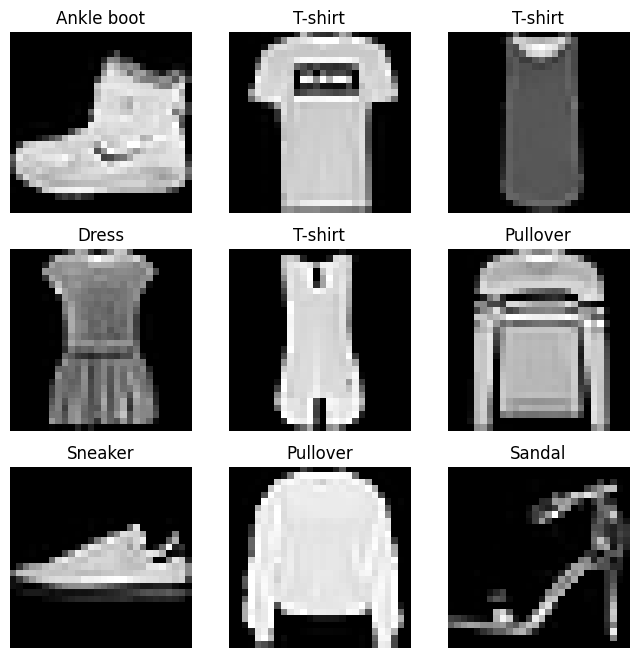

In [4]:
labels = {                                           #Dictionary for storing image name and labels
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

plt.figure(figsize=(8,8))                            #To create a drawing canva for plotting/showing image

for i in range(9):                                   #9 samples for data inspection

    image, label = train_data[i]

    plt.subplot(3,3,i+1)                             #To create a 3x3 grid with image occupying i+1 space|eg, for i=3 space occupied is 4
    plt.imshow(image.squeeze(), cmap="gray")         #To show image and squeeze it to remove extra graycale channel|obtained in grayscale map
    plt.title(labels[label])                         #To show image name above the image
    plt.axis("off")                                  #To hide axis for a clear image

plt.show()                                           #To finally show everything

**CONSTRUCTION OF NEURAL NETWORK**

To create the AI brain

Have contructed a feedforward neural network using PyTorch. The image is flattened from 28×28 into 784 pixels, passed through two hidden layers with ReLU activation, and finally produces 10 output scores corresponding to the FashionMNIST classes."

ReLU function: is like a decision gate and helps neuron detect strong patterns and reject weak signals

#Flowchart
image

↓

flatten

↓

784 pixels

↓

128 neurons

↓

ReLU

↓

64 neurons

↓

ReLU

↓

10 scores

In [5]:
# Blueprint of AI model
class NeuralNetwork(nn.Module):                                    #To make model uing Pytorch Template

    # To construct the AI Brain (It's components)
    def __init__(self):

        super().__init__()                                         #Initializes Python Base module

        self.flatten = nn.Flatten()                                #Flattens: 28x28 to 784

        self.layer1 = nn.Linear(784,128)                           #Hidden layer1: 784 to 128
        self.relu1 = nn.ReLU()                                     #Activation function - Decision gate

        self.layer2 = nn.Linear(128,64)                            #Hidden layer2: 128 to 64
        self.relu2 = nn.ReLU()                                     #Activation function - Decision gate

        self.layer3 = nn.Linear(64,10)                             #Output layer: 10 classes

    #Forward propagation
    def forward(self,x):

        x = self.flatten(x)                                        #Flatten

        x = self.layer1(x)                                         #Hidden layer1
        x = self.relu1(x)

        x = self.layer2(x)                                         #Hidden layer2
        x = self.relu2(x)

        x = self.layer3(x)                                         #Output layer

        return x                                                   #Final scores for prediction

#Real AI model
model = NeuralNetwork()

print(model)                                                       #To show architecture of model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=64, out_features=10, bias=True)
)


**LOSS FUNCTION and OPTIMIZER**

CrossEntropyLoss measures prediction error for classification problems, while SGD optimizer updates model weights using gradients to reduce the loss and improve prediction accuracy

SGD-Stochastic Gradient Descent-use gradients to update weights and reduce losses

lr-Learning Rate-size of weight update

Moderate step size of 0.01 is chosen so that learning process is stable

In [6]:
#To Calculate Loss
loss_function = nn.CrossEntropyLoss()                                            #Loss calculator

#To update weights for AI learning
optimizer = torch.optim.SGD(                                                     #Optimizer
    model.parameters(),                                                          #To update weights in all layers
    lr=0.01                                                                      #Learning rate
)

**Train the AI Brain**

This training function processes batches of images, generates predictions, computes CrossEntropy loss, clears previous gradients, performs backpropagation, updates model weights using SGD, and finally calculates average loss and accuracy for the epoch

Aim is to reduce the loss and increase accuracy after every epoch

In [7]:
def train_model():                                                        #Function for training brain

    model.train()                                                         #Activates training mode

    total_loss = 0
    total_correct = 0
    total_images = 0

    for images, labels in train_loader:                                   #train_loader consists of batches of images
        predictions = model(images)                                       #Gives the 10 output scores for 64 images

        loss = loss_function(                                             #To calculate loss (tensor)
            predictions,
            labels
        )

        optimizer.zero_grad()                                             #To elimiante the old gradients

        loss.backward()                                                   #Backward propagation | suitable gradients are decided

        optimizer.step()                                                  #updation of weights for actual learning

        total_loss += loss.item()                                         #total loss is calculated and tensor is converted to number

        predicted_labels = predictions.argmax(1)                          #Gives the index of highest score output for 64 images

        correct_predictions = (                                           #To check if prediction is correct or not
            predicted_labels == labels
        ).sum().item()                                                    #To sum up for 64 images and convert the tensor to numbers

        total_correct += correct_predictions                              #To calculate total correct predictions

        total_images += labels.size(0)                                    #To calculate total no. of images

    #Average loss
    average_loss = total_loss / len(train_loader)

    #Accuracy
    accuracy = (
        total_correct / total_images
    ) * 100

    return average_loss, accuracy

**TEST FUNCTION**

The testing function evaluates the model on unseen data using eval mode and no_grad to disable gradient calculations. It computes prediction loss and accuracy without updating weights (no learning)

In [8]:
def test_model():                                                          #Testing function

    model.eval()                                                           #Activates testing mode

    total_loss = 0
    total_correct = 0
    total_images = 0

    with torch.no_grad():                                                  #Disables gradient calculations to avoid accident learning

        for images, labels in test_loader:

            predictions = model(images)                                    #Gives the 10 output scores for 64 images

            loss = loss_function(                                          #To calculate loss (tensor)
                predictions,
                labels
            )

            total_loss += loss.item()                                      #total loss is calculated and tensor is converted to number

            predicted_labels = predictions.argmax(1)                       #Gives the index of highest score output for 64 images

            correct_predictions = (                                        #To check if prediction is correct or not
                predicted_labels == labels
            ).sum().item()

            total_correct += correct_predictions                           #To calculate total correct predictions

            total_images += labels.size(0)                                 #To calculate total no. of images


    #Average loss
    average_loss = total_loss / len(test_loader)

    #Accuracy
    accuracy = (
        total_correct / total_images
    ) * 100

    return average_loss, accuracy

**ACTUAL TRAINING LOOP**

The model showed decreasing loss and increasing training and testing accuracy across epochs, indicating successful learning. Final test accuracy reached around 82%, showing good generalization on unseen FashionMNIST images

No case of overfitting is observed here as training and testing accuracy are improving after each epoch

As we have just used neural network a final test accuracy of 82% approx from 66% is respectable

The ouput clearly shows that weights have been properly updated after training and the learning process has been successfully completed

Epoch is greater than 1, so that weights can be further improved with a greater number of rounds. It is limited to 5 in order to ensure that overfitting doesn't take place

In [9]:
epochs = 5

for epoch in range(epochs):

    print("Epoch", epoch + 1)

    train_loss, train_accuracy = train_model()

    test_loss, test_accuracy = test_model()

    print("Training Loss:", train_loss)
    print("Training Accuracy:", train_accuracy)

    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)

    print("-------------------")

Epoch 1
Training Loss: 1.417960405413276
Training Accuracy: 52.14
Test Loss: 0.8757572891605887
Test Accuracy: 65.66
-------------------
Epoch 2
Training Loss: 0.7454605540677682
Training Accuracy: 72.395
Test Loss: 0.6902608341851811
Test Accuracy: 74.83999999999999
-------------------
Epoch 3
Training Loss: 0.613800352633889
Training Accuracy: 78.61
Test Loss: 0.5890522416989514
Test Accuracy: 79.52
-------------------
Epoch 4
Training Loss: 0.5445452117716579
Training Accuracy: 81.2
Test Loss: 0.5421485466182612
Test Accuracy: 80.84
-------------------
Epoch 5
Training Loss: 0.5063116314854703
Training Accuracy: 82.435
Test Loss: 0.5213790887100681
Test Accuracy: 81.41000000000001
-------------------


**TO SAVE TRAINED MODEL**

Pickle was used to serialize and save the trained model weights stored in state_dict into a .pkl file for reuse

state_dict() creates a dictionary storing the learned weights and biases for every layer of the ai model

File name is fashion_model and pkl is Pickle extension

In [10]:
import pickle                                                              #Python saving object

with open("fashion_model.pkl", "wb") as file:                              #creates a binary file

    pickle.dump(                                                           #loads the trained weights into this file
        model.state_dict(),
        file
    )

print("Pickle Model Saved Successfully!")

Pickle Model Saved Successfully!


**LOAD SAVED MODEL and MAKE PREDICTIONS**

A new model object is created and the saved pickle weights are loaded into state_dict, restoring the trained network for prediction

In [11]:
loaded_model = NeuralNetwork()                                            #new empty brain

import pickle

with open("fashion_model.pkl", "rb") as file:                             #To read the trained weights

    saved_weights = pickle.load(file)                                     #To extract trained weights

loaded_model.load_state_dict(                                             #Put trained weights into empty brain
    saved_weights
)

loaded_model.eval()                                                       #Activates testing mode

print("Pickle Model Loaded Successfully!")

Pickle Model Loaded Successfully!


**FINAL PREDICTION and IMAGE DISPLAY**

A test image is taken and reshaped into a batch using unsqueeze. The trained model predicts class scores, argmax selects the highest-scoring class, and the predicted index is converted into a clothing label using a dictionary

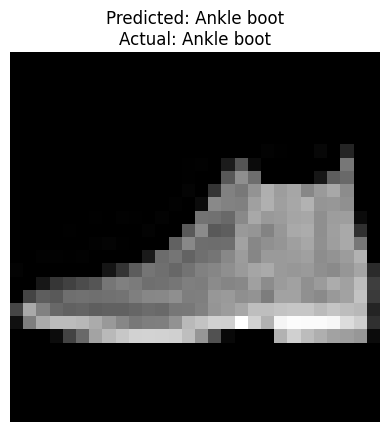

Predicted: Ankle boot
Actual: Ankle boot


In [12]:
labels_map = {                                                              #Dictionary for storing image name and labels
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

image, true_label = test_data[0]                                            #take the first iamge

image_batch = image.unsqueeze(0)                                            #To add the extra dimension to make image batches

with torch.no_grad():                                                       #To eliminate gradient calculation

    prediction = loaded_model(image_batch)                                  #Gives 10 output scores

predicted_label = prediction.argmax(1).item()                               #index of highest output score and converts tensor to number

#To display the image
plt.imshow(
    image.squeeze(),                                                        #To remove extra channel dimension
    cmap="gray"                                                             #To show image in grayscale
)

plt.title(
    "Predicted: " +
    labels_map[predicted_label]
    +
    "\nActual: " +
    labels_map[true_label]
)

plt.axis("off")                                                             #To hide axis

plt.show()

#AI prediction
print(
    "Predicted:",
    labels_map[predicted_label]
)

#Actual clothing type
print(
    "Actual:",
    labels_map[true_label]
)

plt.show()                                                                  #To finally show everything

**LOSS and ACCURACY GRAPH vs Epoch**

Graphs help visualize model learning behaviour across epochs. Loss graphs show whether error decreases, while accuracy graphs show whether prediction performance improves and help detect overfitting.

Here the loss graph decreases and the accuracy graph increases

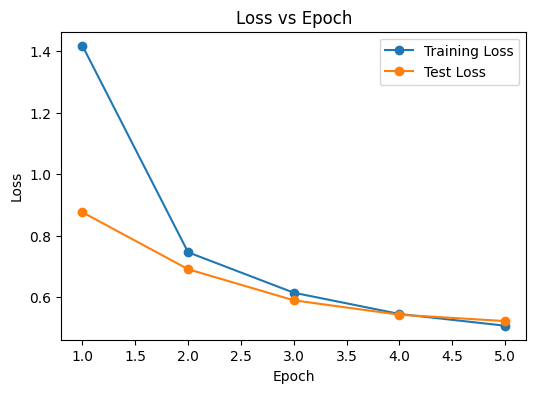

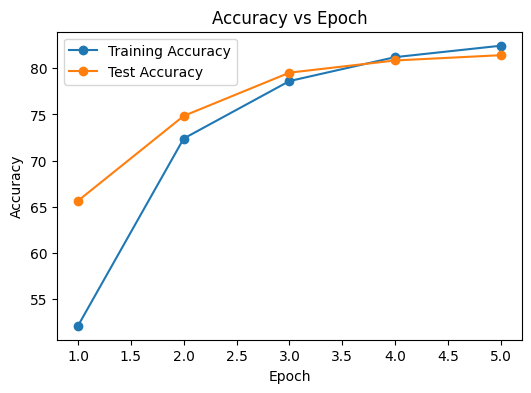

In [14]:
import matplotlib.pyplot as plt                                           #drawing tool

epochs_range = [1, 2, 3, 4, 5]                                            #X-Axis

train_losses = [
    1.417960405413276,
    0.7454605540677682,
    0.613800352633889,
    0.5445452117716579,
    0.5063116314854703
]

test_losses = [
    0.8757572891605887,
    0.6902608341851811,
    0.5890522416989514,
    0.5421485466182612,
    0.5213790887100681
]

train_accuracies = [
    52.14,
    72.395,
    78.61,
    81.2,
    82.435
]

test_accuracies = [
    65.66,
    74.84,
    79.52,
    80.84,
    81.41
]

plt.figure(figsize=(6,4))                                                 #creates graph canva of required size

#To plot training and test losses againt epoch
plt.plot(epochs_range, train_losses, marker='o')
plt.plot(epochs_range, test_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend(["Training Loss", "Test Loss"])
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_accuracies, marker='o')
plt.plot(epochs_range, test_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend(["Training Accuracy", "Test Accuracy"])
plt.show()

**CREATE submission.csv**

The trained model was used in evaluation mode to predict labels for all test batches. Predictions were collected into a list, converted into a pandas DataFrame, and saved as submission.csv using to_csv

In [15]:
import pandas as pd                                                 #Tool to crete tables and spreadsheets

predictions_list = []                                               #list to store ai predicted labels

loaded_model.eval()                                                 #Activates testing mode

with torch.no_grad():                                               #eliminates gradient calculation

    for images, labels in test_loader:

        outputs = loaded_model(images)                              #Gives 10 output scores for 64 images

        predicted = outputs.argmax(1)                               #index of highest output score

        predictions_list.extend(
            predicted.tolist()                                      #To add predicted labels to list and tolist is used to convert tensor to number
        )

submission = pd.DataFrame({                                         #To create table
    "Id": range(len(predictions_list)),
    "Prediction": predictions_list
})

#To save table as csv file
submission.to_csv(
    "submission.csv",                                              #file name
    index=False                                                    #To remove index,that is, extra column
)

print("submission.csv created successfully!")

submission.csv created successfully!
